In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import joblib

In [71]:
#load dataset
df=pd.read_csv(r"C:\Users\USER\Downloads\boston (1).csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [72]:
#EDA
print(df.dtypes,"\n")
print(df.shape,"\n")
df.info()

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object 

(506, 14) 

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtyp

In [73]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [74]:
#check any missing values
df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

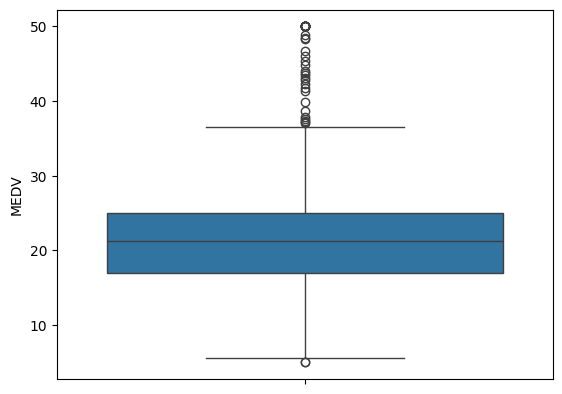

In [75]:
#check outliers in target
sns.boxplot(df["MEDV"])
plt.show()

In [76]:
#remove outliers
Q1=df["MEDV"].quantile(0.25)
Q3=df["MEDV"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
df=df[(df["MEDV"]>lower_limit)&(df["MEDV"]<upper_limit)]
print(df.shape)

(466, 14)


In [77]:
#features and target
x1=df.drop("MEDV",axis=1)
y=df["MEDV"]
#remove less importance features to reduce overfitting
x=x1.drop(["CHAS","ZN"],axis=1)

In [78]:
#divide numerical and binary columns
num_cols=x.select_dtypes(["float64"]).columns
bin_cols=x.select_dtypes(["int64"]).columns

In [79]:
preprocessor=ColumnTransformer([
    ("num_scale",StandardScaler(),num_cols),
    ("keep_binary","passthrough",bin_cols)
])

In [80]:
model=Pipeline([
    ("preprocess",preprocessor),
    ("model",LinearRegression())
])

In [81]:
#split the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [82]:
##train the model
model_RF=Pipeline([
    ("preprocess",preprocessor),
    ("model_RF",RandomForestRegressor(n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42))
])
model_RF.fit(x_train,y_train)

#save model
joblib.dump(model_RF,"boston_house.pkl")


['boston_house.pkl']

In [83]:
#evaluation
y_pred_train=model_RF.predict(x_train)
train_acc=r2_score(y_pred_train,y_train)
print("Train accuracy",train_acc)

y_pred_test=model_RF.predict(x_test)
test_acc=r2_score(y_pred_test,y_test)
print("Test accuracy",test_acc)
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("RMSE:", root_mean_squared_error(y_test, y_pred_test))

Train accuracy 0.8356037982397913
Test accuracy 0.6912741774990916
MAE: 2.124058543592613
MSE: 7.640546138190128
RMSE: 2.7641537833829233


In [84]:
#cross validation
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model_RF,x,y,cv=5)
print(scores.mean())

0.5551516025661981


In [85]:
#feaures selection
#from sklearn.metrics import feature_importances_
importance=model_RF.named_steps["model_RF"].feature_importances_
feature_names=preprocessor.get_feature_names_out()
sorted_features=sorted(zip(feature_names,importance),key=lambda x:x[1],reverse=True)
for name,score in sorted_features:
    print(name,":",score)

num_scale__LSTAT : 0.27816188110954243
num_scale__RM : 0.18895835207432338
num_scale__NOX : 0.09893666192461845
num_scale__PTRATIO : 0.09294064718974729
num_scale__CRIM : 0.09101333578791207
num_scale__INDUS : 0.08272767237548807
num_scale__TAX : 0.06865994638377541
num_scale__DIS : 0.04276004683206545
num_scale__AGE : 0.03281471397157056
num_scale__B : 0.014720530279860033
keep_binary__RAD : 0.008306212071096936
